## Импорт библиотек и загрузка данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATASET = "https://raw.githubusercontent.com/aiedu-courses/eda_and_dev_tools/main/datasets/abalone.csv"

In [ ]:
df = pd.read_csv(DATASET)


* `Sex` - половой признак: M (самец), F (самка), I (детёныш)
* `Length` - наибольшая длина раковины
* `Diameter` - диаметр, перпендикулярный длине
* `Height` - высота с мясом внутри раковины
* `Whole weight` - масса всего абалона
* `Shucked weight` - масса мяса
* `Viscera weight` - масса внутренностей (после удаления крови)
* `Shell weight` - масса раковины после сушки
* `Rings` - +1,5 дает возраст в годах (целевой возраст)

In [ ]:
df.head(10)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,NaN,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,F,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


Посмотрим на данные

<Axes: xlabel='Sex', ylabel='sex_counts'>

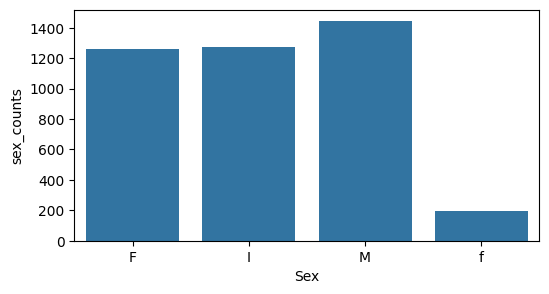

In [ ]:
sex = df.groupby('Sex', as_index=False) \
    .agg({'Rings': 'count'}) \
    .rename(columns={'Rings': 'sex_counts'})


plt.figure(figsize=(6, 3))
sns.barplot(data=sex, x=sex['Sex'], y=sex['sex_counts'])

Есть опечатки так как нет категории f, поэтому переименуем на F

In [ ]:
df.loc[df['Sex'] == 'f', 'Sex'] = 'F'

<Axes: xlabel='Sex', ylabel='sex_counts'>

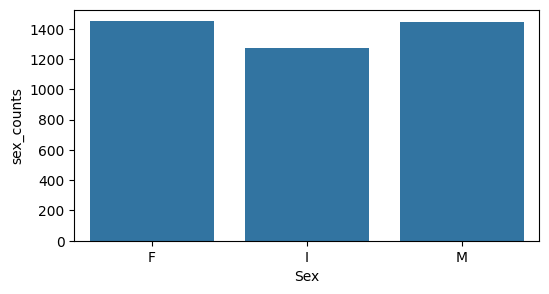

In [ ]:
sex = df.groupby('Sex', as_index=False) \
    .agg({'Rings': 'count'}) \
    .rename(columns={'Rings': 'sex_counts'})


plt.figure(figsize=(6, 3))
sns.barplot(data=sex, x=sex['Sex'], y=sex['sex_counts'])

Теперь все верно

# Построение моделей на числовых признаках

In [ ]:
df.isnull().mean() * 100 # в датасете есть пропуски надо заполнить их средними значениями

,0
Sex,0.000000
Length,0.000000
Diameter,2.370122
Height,0.000000
Whole weight,2.370122
Shucked weight,0.000000
Viscera weight,0.000000
Shell weight,1.197031
Rings,0.000000


In [ ]:
median_diameter = df['Diameter'].median()

median_weight = df['Whole weight'].median()

median_shell = df['Shell weight'].median()

print(median_diameter, median_weight, median_shell)

0.425 0.7985 0.235


In [ ]:
df['Diameter'] = df['Diameter'].fillna(median_diameter)

In [ ]:
df['Whole weight'] = df['Whole weight'].fillna(median_weight)

In [ ]:
df['Shell weight'] = df['Shell weight'].fillna(median_shell)

In [ ]:
df.isnull().mean() * 100 # проверка замены

,0
Sex,0.0
Length,0.0
Diameter,0.0
Height,0.0
Whole weight,0.0
Shucked weight,0.0
Viscera weight,0.0
Shell weight,0.0
Rings,0.0


Замены выполнены, пропусков больше нет

## 1. Построение моделей на числовых признаках (минимум - NB и kNN, максимум - любые) с параметрами по умолчанию, вычисление метрик + комментарий о качестве моделей

### NB - Наивный байесовский классификатор

Смотрим какие есть численные значения и их количество

<Axes: xlabel='Rings', ylabel='Count'>

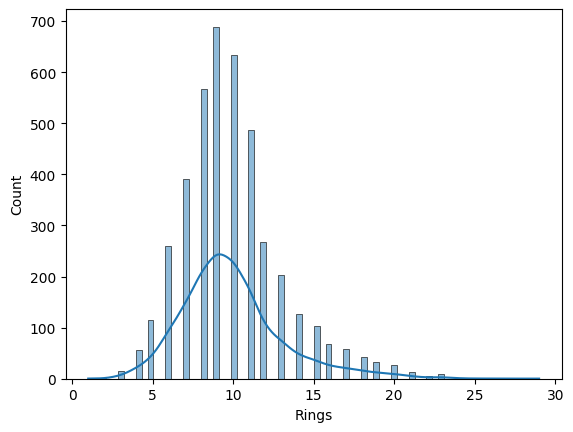

In [ ]:
sns.histplot(data = df['Rings'], kde = True)

In [ ]:
df['Rings'].value_counts()

,count
Rings,
9,689
10,634
8,568
11,487
7,391
12,267
6,259
13,203
14,126


По гистограмме и уникальным значениям в столбце Rings можно увидеть, что числа разбросаны в диапазоне от 1 до 29. Можно разбить данные по возрасту = 12, где возраст меньше 12 это молодые у них будет метка 0, а больше старые у них метка 1

In [ ]:
X = df[['Length','Diameter','Height',"Whole weight","Shucked weight","Viscera weight", "Shell weight"]]
y = df['Rings']

y_class = (y > 12).astype(int)

Поменяем числовые данные на бинарный алфавит в графе Rings

In [ ]:
y_class.value_counts()

,count
Rings,
0,3484
1,693


поровну не получилось - это плохо, можно попробовать взять медиану

In [ ]:
y.median()

9.0

In [ ]:
y_class = (y > 9).astype(int) # использую медиану

In [ ]:
y_class.value_counts()

,count
Rings,
0,2096
1,2081


Практически поровну это лучше, так как позволит более точно обучить модель

Разделяем данные на train и test

Train (обучающая выборка) — данные, на которых модель обучается

Test (тестовая выборка) — данные, которые модель не видела во время обучения

train - 75%
test - 25%

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.25, random_state=42)

Можно посмотреть сколько объектов ушло в train и сколько в test

In [ ]:
X_train.shape, X_test.shape

((3132, 7), (1045, 7))

3132 - train

1045 - test

In [ ]:
from sklearn.naive_bayes import GaussianNB # используем Байесовский классификатор так как работаем с численными даннами

gnb = GaussianNB() # объявляем модель

gnb.fit(X_train, y_train) # обучаем на тренировачных данных

y_pred = gnb.predict(X_test) # делаем прогноз на тесте

Модель обучена, можно посмотреть на несколько прогнозов

In [ ]:
y_pred[:10]

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 1])

То есть первые 4 абалона модель считает старыми, а 5 последних молодыми

Можно также посмотреть правильные ответы и сравнить с предсказанными значениями модели

In [ ]:
y_test[:10].values

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1])

Достаточно много модель не угадывает, поэтому посмотрим на всех данных

In [ ]:
from sklearn.metrics import accuracy_score #доля правильных ответов

accuracy_score(y_test, y_pred)

0.7301435406698564

Среди всех данных модель определила верно класс в 73% - в целом не плохо

Не понятно с чем модель имеет ошибки, поэтому можно построить матрицу и посмотреть, где наибольшие промахи

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[387, 147],
       [135, 376]])

Из матрицы можно понять, что среди всех абалонов 387 молодых модель определила верно, а 147 модель назвала старыми, хотя они молодые, то есть это ошибка

Вторая строчка это старые абалоны, где 135 модель назвала молодыми, а 376 определила верно

Вывод модель чаще ошибается, называя старыми молодых, но в целом эта разница не сильно большая

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler #для масштабирования данных

scaler = MinMaxScaler() # объявляем, что хотим масштабировать данные
scaler.fit(X_train) # обучаем

X_train_scaled = scaler.transform(X_train) # масштабируем тренировачные данные
X_test_scaled = scaler.transform(X_test) # масштабируем тестовые данные


knn_cl = KNeighborsClassifier() # объявляем метод

knn_cl.fit(X_train_scaled, y_train) # обучаем

pred_knn = knn_cl.predict(X_test_scaled) # делаем прогноз

Проверка, все ли сработало

In [ ]:
X_train_scaled

array([[0.72972973, 0.67226891, 0.11946903, ..., 0.31775387, 0.34562212,
        0.27154958],
       [0.59459459, 0.57142857, 0.12389381, ..., 0.18829859, 0.16458196,
        0.21773792],
       [0.79054054, 0.79831933, 0.15486726, ..., 0.49663753, 0.46082949,
        0.40209268],
       ...,
       [0.58783784, 0.57142857, 0.11061947, ..., 0.16341627, 0.17511521,
        0.18584953],
       [0.67567568, 0.68907563, 0.10619469, ..., 0.3463349 , 0.28703094,
        0.2326856 ],
       [0.7027027 , 0.70588235, 0.14159292, ..., 0.36718225, 0.30348914,
        0.26856004]])

Все отмасштабировалось, теперь значения от 0 до 1

In [ ]:
accuracy_score(y_test, pred_knn)

0.7703349282296651

Модель отвечает верно в 77% случаев

In [ ]:
confusion_matrix(y_test, pred_knn)

array([[407, 127],
       [113, 398]])

В сравнение с методом NB, метод ближайших соседей работает лучше и имеет меньше ошибок, сами же ошибки похожи так как немного больше их, когда модель пытается определить молодой абалон, но определяет его как старый

## 2. Подбор гиперпараметров у каждой из моделей (только на числовых признаках) при помощи GridSearchCV + вычисление метрик для лучших найденных моделей + текстовый комментарий

GridSearchCV - это метод подбора гиперпараметров модели машинного обучения, который перебирает все заданные комбинации параметров и оценивает каждую из них с помощью кросс-валидации, чтобы выбрать набор параметров, дающий наилучшее значение выбранной метрики качества.

Перебор гиперпараметров по сетке

GridSearchCV на KNN

In [ ]:
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.25, random_state=42) # отдельно валидацию делать не надо, функция сама все сделает

model = KNeighborsClassifier() # объявляем модель, у которой хотим подобрать гиперпараметр

# задаем словарь из гиперпараметров, которые интересны
params = {'n_neighbors' : np.arange(2, 20, 2),
          'weights' : ['uniform', 'distance'],
          'p' : [1, 2]}

gs = GridSearchCV(model, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

Так как рассматриваем KNN, то основные гиперпараметры, которые обычно подбирают через GridSearchCV, такие:

1. n_neighbors — число соседей

2. weights — способ голосования - ['uniform', 'distance']

        uniform — все соседи равны
        distance — ближние соседи важнее


3. p — метрика расстояния в Minkowski

        1 — Manhattan
        2 — Euclidean (по умолчанию)

In [ ]:
gs.best_score_, gs.best_params_

(np.float64(0.7854406130268199),
 {'n_neighbors': np.int64(12), 'p': 2, 'weights': 'distance'})

##Модель нашла наилучшие гиперпараметры

Надо брать 12 соседей

Евклидовое расстаяние

Ближние соседи важнее

После того как модель обучена, можно взять наилучшую модель с наилучшими гиперпараметрами и сделать прогноз на тесте

In [ ]:
pred = gs.best_estimator_.predict(X_test)
accuracy_score(y_test, pred)

0.785645933014354

Теперь модель работает лучше и имеет правильные ответы в 78%-79% случаев

In [ ]:
confusion_matrix(y_test, pred)

array([[417, 117],
       [107, 404]])

Модель имеет все такие же ошибки в тех же пропорциях, но их меньше

GridSearchCV на NB

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV


X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.25, random_state=42)


model = GaussianNB()# модель NB

# словарь гиперпараметров для подбора
params = {
    'var_smoothing': np.logspace(-12, -6, 20)
}

# GridSearchCV
gs = GridSearchCV(model, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


GridSearchCV(cv=3, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': array([1.00000000e-12, 2.06913808e-12, 4.28133240e-12, 8.85866790e-12,
       1.83298071e-11, 3.79269019e-11, 7.84759970e-11, 1.62377674e-10,
       3.35981829e-10, 6.95192796e-10, 1.43844989e-09, 2.97635144e-09,
       6.15848211e-09, 1.27427499e-08, 2.63665090e-08, 5.45559478e-08,
       1.12883789e-07, 2.33572147e-07, 4.83293024e-07, 1.00000000e-06])},
             scoring='accuracy', verbose=2)

In [ ]:
gs.best_score_, gs.best_params_

(np.float64(0.7349936143039592), {'var_smoothing': np.float64(1e-12)})

In [ ]:
pred = gs.best_estimator_.predict(X_test)
accuracy_score(y_test, pred)

0.7301435406698564

Разницы NB и NB с применением GridSearchCV нет

## 3. Добавление категориальных признаков в лучшую модель, обучение модели и заново подбор ее гиперпараметров + вычисление метрик + текстовый комментарий

Лучшей модулью была KNN

Для добавнелия категориальных признаков изпользуем One-Hot Encoded

In [ ]:
X_full = df.drop('Rings', axis=1)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_class, test_size=0.25, random_state=42)

In [ ]:
X_train_full.dtypes

,0
Sex,object
Length,float64
Diameter,float64
Height,float64
Whole weight,float64
Shucked weight,float64
Viscera weight,float64
Shell weight,float64


Есть один категориальный признак - sex, его надо закодировать

In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

categorical = ['Sex']
numeric_features = ['Length', 'Diameter', 'Height', "Whole weight", "Shucked weight", "Viscera weight", "Shell weight"]

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', MinMaxScaler(), numeric_features)
])

X_train_transformed = ct.fit_transform(X_train_full)
X_test_transformed = ct.transform(X_test_full)

In [ ]:
new_features = list(ct.named_transformers_['ohe'].get_feature_names_out())
new_features.extend(numeric_features)

new_features

['Sex_F',
 'Sex_I',
 'Sex_M',
 'Length',
 'Diameter',
 'Height',
 'Whole weight',
 'Shucked weight',
 'Viscera weight',
 'Shell weight']

Получилось после преобрвзований:

In [ ]:
X_train_transformed

array([[1.        , 0.        , 0.        , ..., 0.31775387, 0.34562212,
        0.27154958],
       [1.        , 0.        , 0.        , ..., 0.18829859, 0.16458196,
        0.21773792],
       [0.        , 0.        , 1.        , ..., 0.49663753, 0.46082949,
        0.40209268],
       ...,
       [0.        , 0.        , 1.        , ..., 0.16341627, 0.17511521,
        0.18584953],
       [0.        , 0.        , 1.        , ..., 0.3463349 , 0.28703094,
        0.2326856 ],
       [1.        , 0.        , 0.        , ..., 0.36718225, 0.30348914,
        0.26856004]])

Не очень удобно выглядит, надо вернуть названия столбцов. Сначала я их возьму после того как OneHotEncoder отработал и затем добавлю их к данным

In [ ]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=new_features)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=new_features)

X_train_transformed.head(10)

,Sex_F,Sex_I,Sex_M,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,1.0,0.0,0.0,0.729730,0.672269,0.119469,0.374358,0.317754,0.345622,0.271550
1,1.0,0.0,0.0,0.594595,0.571429,0.123894,0.242253,0.188299,0.164582,0.217738
2,0.0,0.0,1.0,0.790541,0.798319,0.154867,0.559943,0.496638,0.460829,0.402093
3,0.0,0.0,1.0,0.513514,0.521008,0.084071,0.181335,0.150303,0.132324,0.147982
4,0.0,0.0,1.0,0.567568,0.579832,0.137168,0.285638,0.157028,0.151415,0.347285
5,0.0,0.0,1.0,0.743243,0.747899,0.159292,0.484682,0.433087,0.398288,0.367713
6,0.0,1.0,0.0,0.418919,0.378151,0.088496,0.096866,0.087088,0.079658,0.070752
7,0.0,1.0,0.0,0.452703,0.453782,0.088496,0.114220,0.088097,0.094141,0.104136
8,1.0,0.0,0.0,0.385135,0.369748,0.075221,0.069240,0.049428,0.053983,0.068261
9,1.0,0.0,0.0,0.554054,0.529412,0.115044,0.185585,0.166443,0.137591,0.153463


На этом этапе я увидела, что в изначальных данных были ошибки с регистром Sex_F и Sex_f это одно и тоже, поэтому переименуем ошибочные данные, я это сделала в самом начале и запустила заново

На первых данных визуально ошибок нет, все сработало корректно

In [ ]:
model = KNeighborsClassifier()

params = {'n_neighbors' : np.arange(2, 20, 2),
          'weights' : ['uniform', 'distance']}


gs = GridSearchCV(model, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)
gs.fit(X_train_transformed, y_train_full)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [ ]:
gs.best_score_, gs.best_params_

(np.float64(0.780332056194125),
 {'n_neighbors': np.int64(16), 'weights': 'distance'})

In [ ]:
pred = gs.best_estimator_.predict(X_test_transformed)

accuracy_score(y_test_full, pred)

0.7779904306220096

Было - 0.785  Стало - 0.777 Качество на 0.008 понизилось

Вывод: модель немного ухудшила свою работу. Я думаю, это может быть связано с тем, что мало данных и модель начинает плохо обобщать данные. В таком случае я бы попробовала другой метод вместо OHE.

## 4. Построение Explainer Dashboard

In [ ]:
!pip install pyngrok -q
!pip install explainerdashboard -q

In [ ]:
!ngrok config add-authtoken 39eYmAmHjtjoOfmTtx3DT3CV6fP_3D39e9xYDtL8hzL7z5rSh

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
from explainerdashboard import ClassifierExplainer, ExplainerDashboard

In [ ]:
explainer = ClassifierExplainer(
    gs.best_estimator_,
    X_test_transformed,
    y_test_full
)

/usr/local/lib/python3.12/dist-packages/explainerdashboard/explainers.py:403: UserWarning: WARNING: Parameter shap='guess', but failed to guess the type of shap explainer to use for KNeighborsClassifier. Defaulting to the model agnostic shap.KernelExplainer (shap='kernel'). However this will be slow, so if your model is compatible with e.g. shap.TreeExplainer or shap.LinearExplainer then pass shap='tree' or shap='linear'!
/usr/local/lib/python3.12/dist-packages/explainerdashboard/explainers.py:425: UserWarning: For shap='kernel', shap interaction values cannot be calculated.
/usr/local/lib/python3.12/dist-packages/explainerdashboard/explainers.py:3293: UserWarning: Shap values for shap='kernel' normally get calculated against X_background, but X_background=None, so setting X_background=shap.sample(X, 50)...


In [ ]:
db = ExplainerDashboard(explainer, port=8050)

/usr/local/lib/python3.12/dist-packages/explainerdashboard/dashboards.py:697: UserWarning: WARNING: the number of idxs (=1045) > max_idxs_in_dropdown(=1000). However with your installed version of dash(4.0.0) dropdown search may not work smoothly. You can downgrade to `pip install dash==2.6.2` which should work better for now...
/usr/local/lib/python3.12/dist-packages/explainerdashboard/dashboards.py:717: UserWarning: Detected google colab environment, setting mode='external'.
/usr/local/lib/python3.12/dist-packages/dash/dash.py:644: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.

/usr/local/lib/python3.12/dist-packages/explainerdashboard/dashboards.py:815: UserWarning:

For this type of model and model_output interactions don't work, so setting shap_interaction=False...

/usr/local/lib/python3.12/dist-packages/explainerdashboard/dashboards.py:822: UserWarning:

The explainer object has no decision_trees property

  0%|          | 0/1045 [00:00<?, ?it/s]

In [ ]:
public_url = ngrok.connect(8050)
print("Dashboard URL:", public_url)

Dashboard URL: NgrokTunnel: "https://isla-choric-daringly.ngrok-free.dev" -> "http://localhost:8050"


In [ ]:
db.run(use_reloader=False)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app 'explainerdashboard.dashboards'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [15/Feb/2026 19:50:29] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Feb/2026 19:50:30] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_0_0m1771182639.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Feb/2026 19:50:30] "GET /_dash-component-suites/dash/html/dash_html_components.v4_0_0m1771182639.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Feb/2026 19:50:30] "GET /assets/bootstrap.min.css?m=1771182640.192011 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Feb/2026 19:50:30] "GET /_dash-component-suites/dash/deps/react@18.v4_0_0m1771182639.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Feb/2026 19:50:30] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_0_0m1771182639.min.js HTTP/1.1" 200 -

## Анализ модели в Explainer Dashboard

*   какие факторы наиболее важны в среднем для получения прогноза?




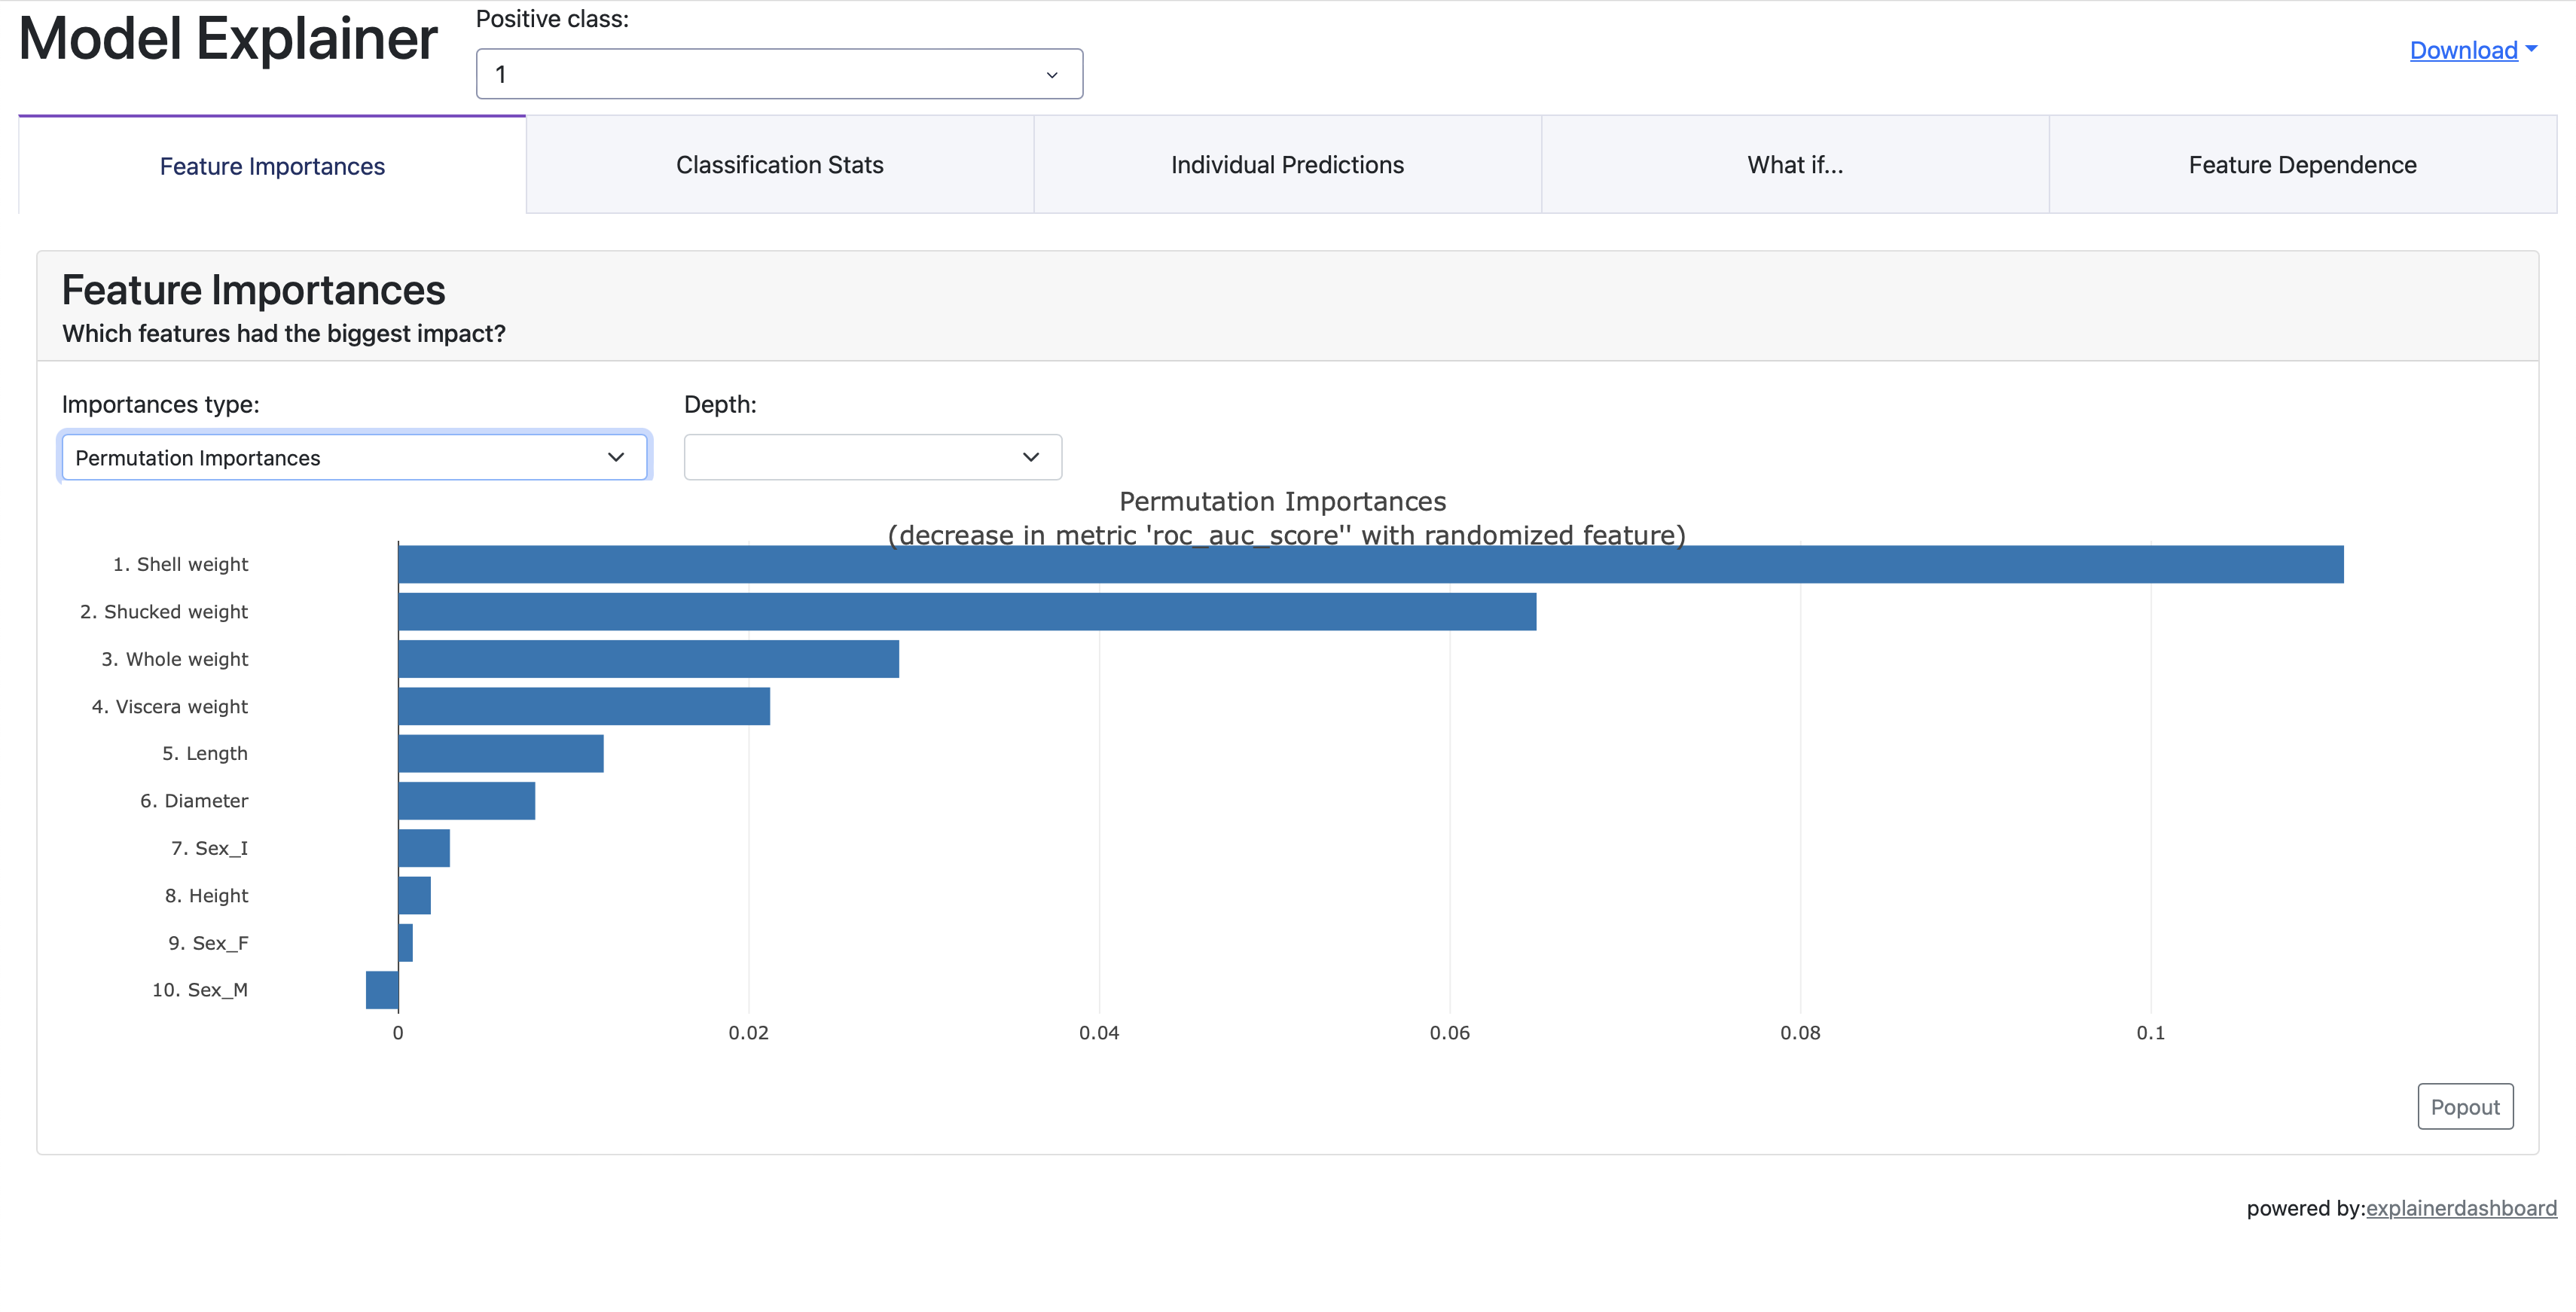

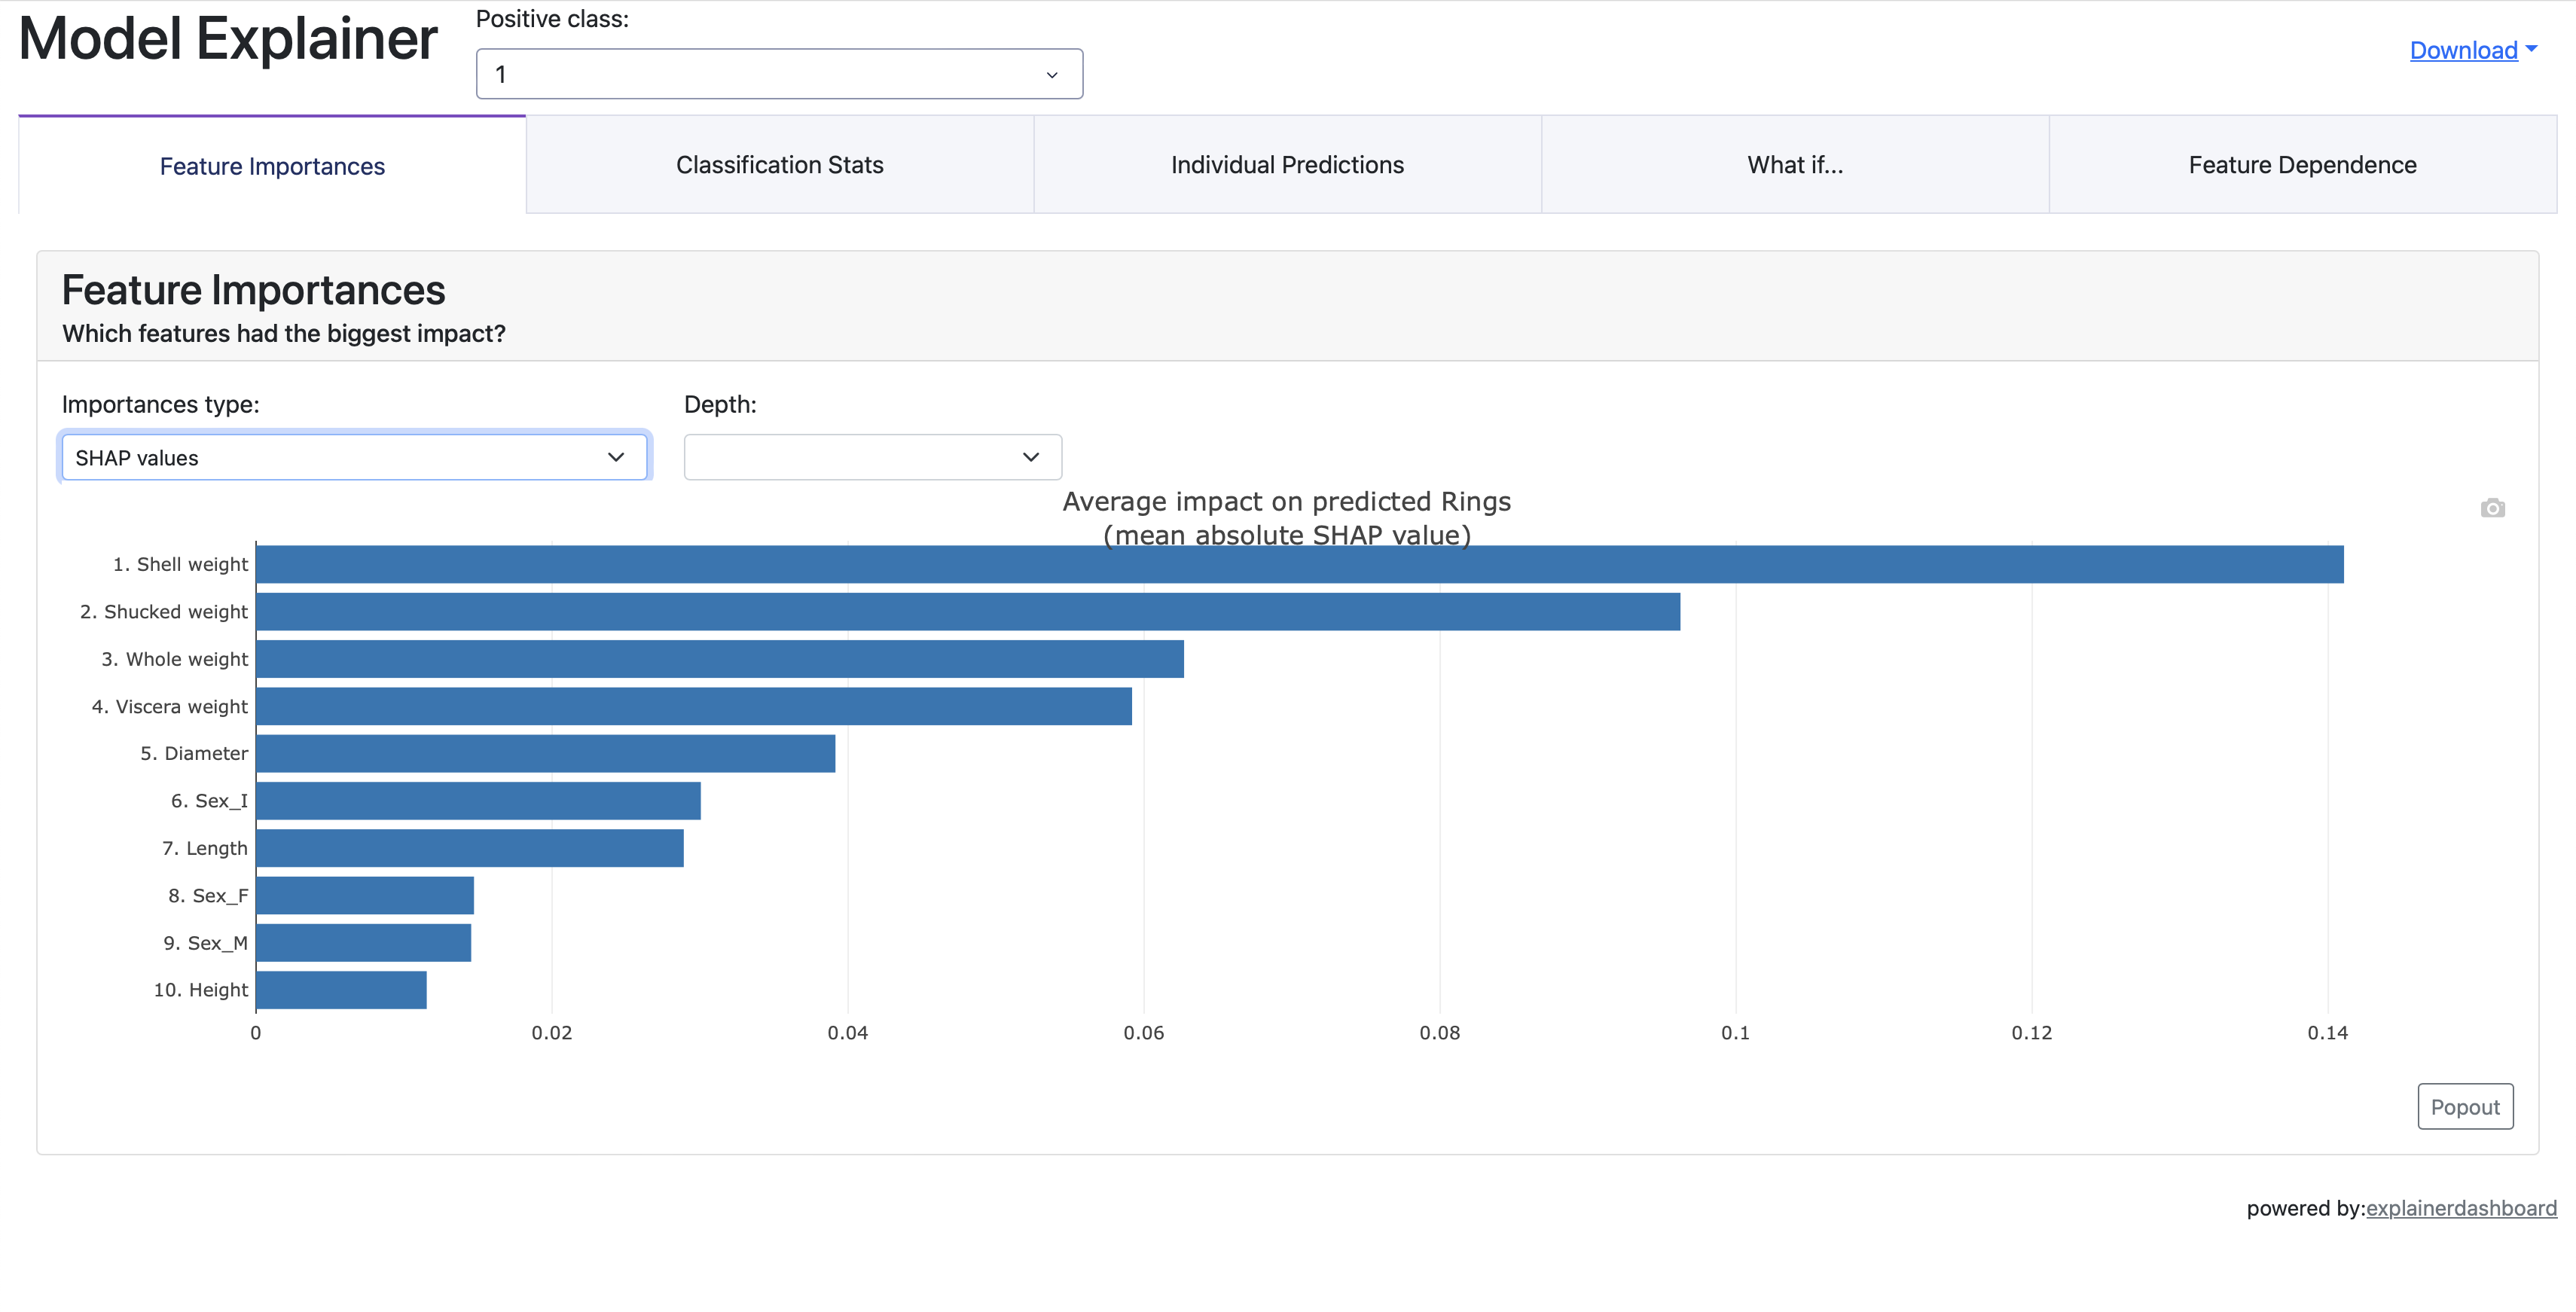

Есть 2 типа подхода по которым можно определетить какие признаки наиболее важны и их ответы могут отличаться

### 1.   Permutation Importances
  Самый важный - Shell weight

  Также важны - Shucked weight и Whole weight


### 2.   SHAP values
  Самый важный - Shell weight

  Также важны - Shucked weight и Whole weight


Вывод: нет различий в самых влиятельных факторах, значит они действительно имеют сильное значение на результат

*   какие значения метрик получились и что это значит?




## Permutation importance

1.   Shell weight - 0.15
2.   Shucked weight - 0.052
3.   Whole weight - 0.03

## SHAP values

1.   Shell weight - 0.142
2.   Shucked weight - 0.088
3.   Whole weight - 0.063

Pedrmutation importance не дает понимания какой именно вклад категория дает в ответ. Этот тип помагает определить важность, но насколько он дает значимость в ответ - нет, поэтому SHAP values дает как вклад признака влияет на ответ

То есть вклад в ответ Shell weight самый значимый, но он же дает большую важность

Если смотреть на второе и третье место, то там аналогичная ситуация с Shucked weight и Whole weight

*  анализ 2-3 индивидуальных прогнозов с комментарием

0 - означает, что абаллон молодой

1 - означает, что старый



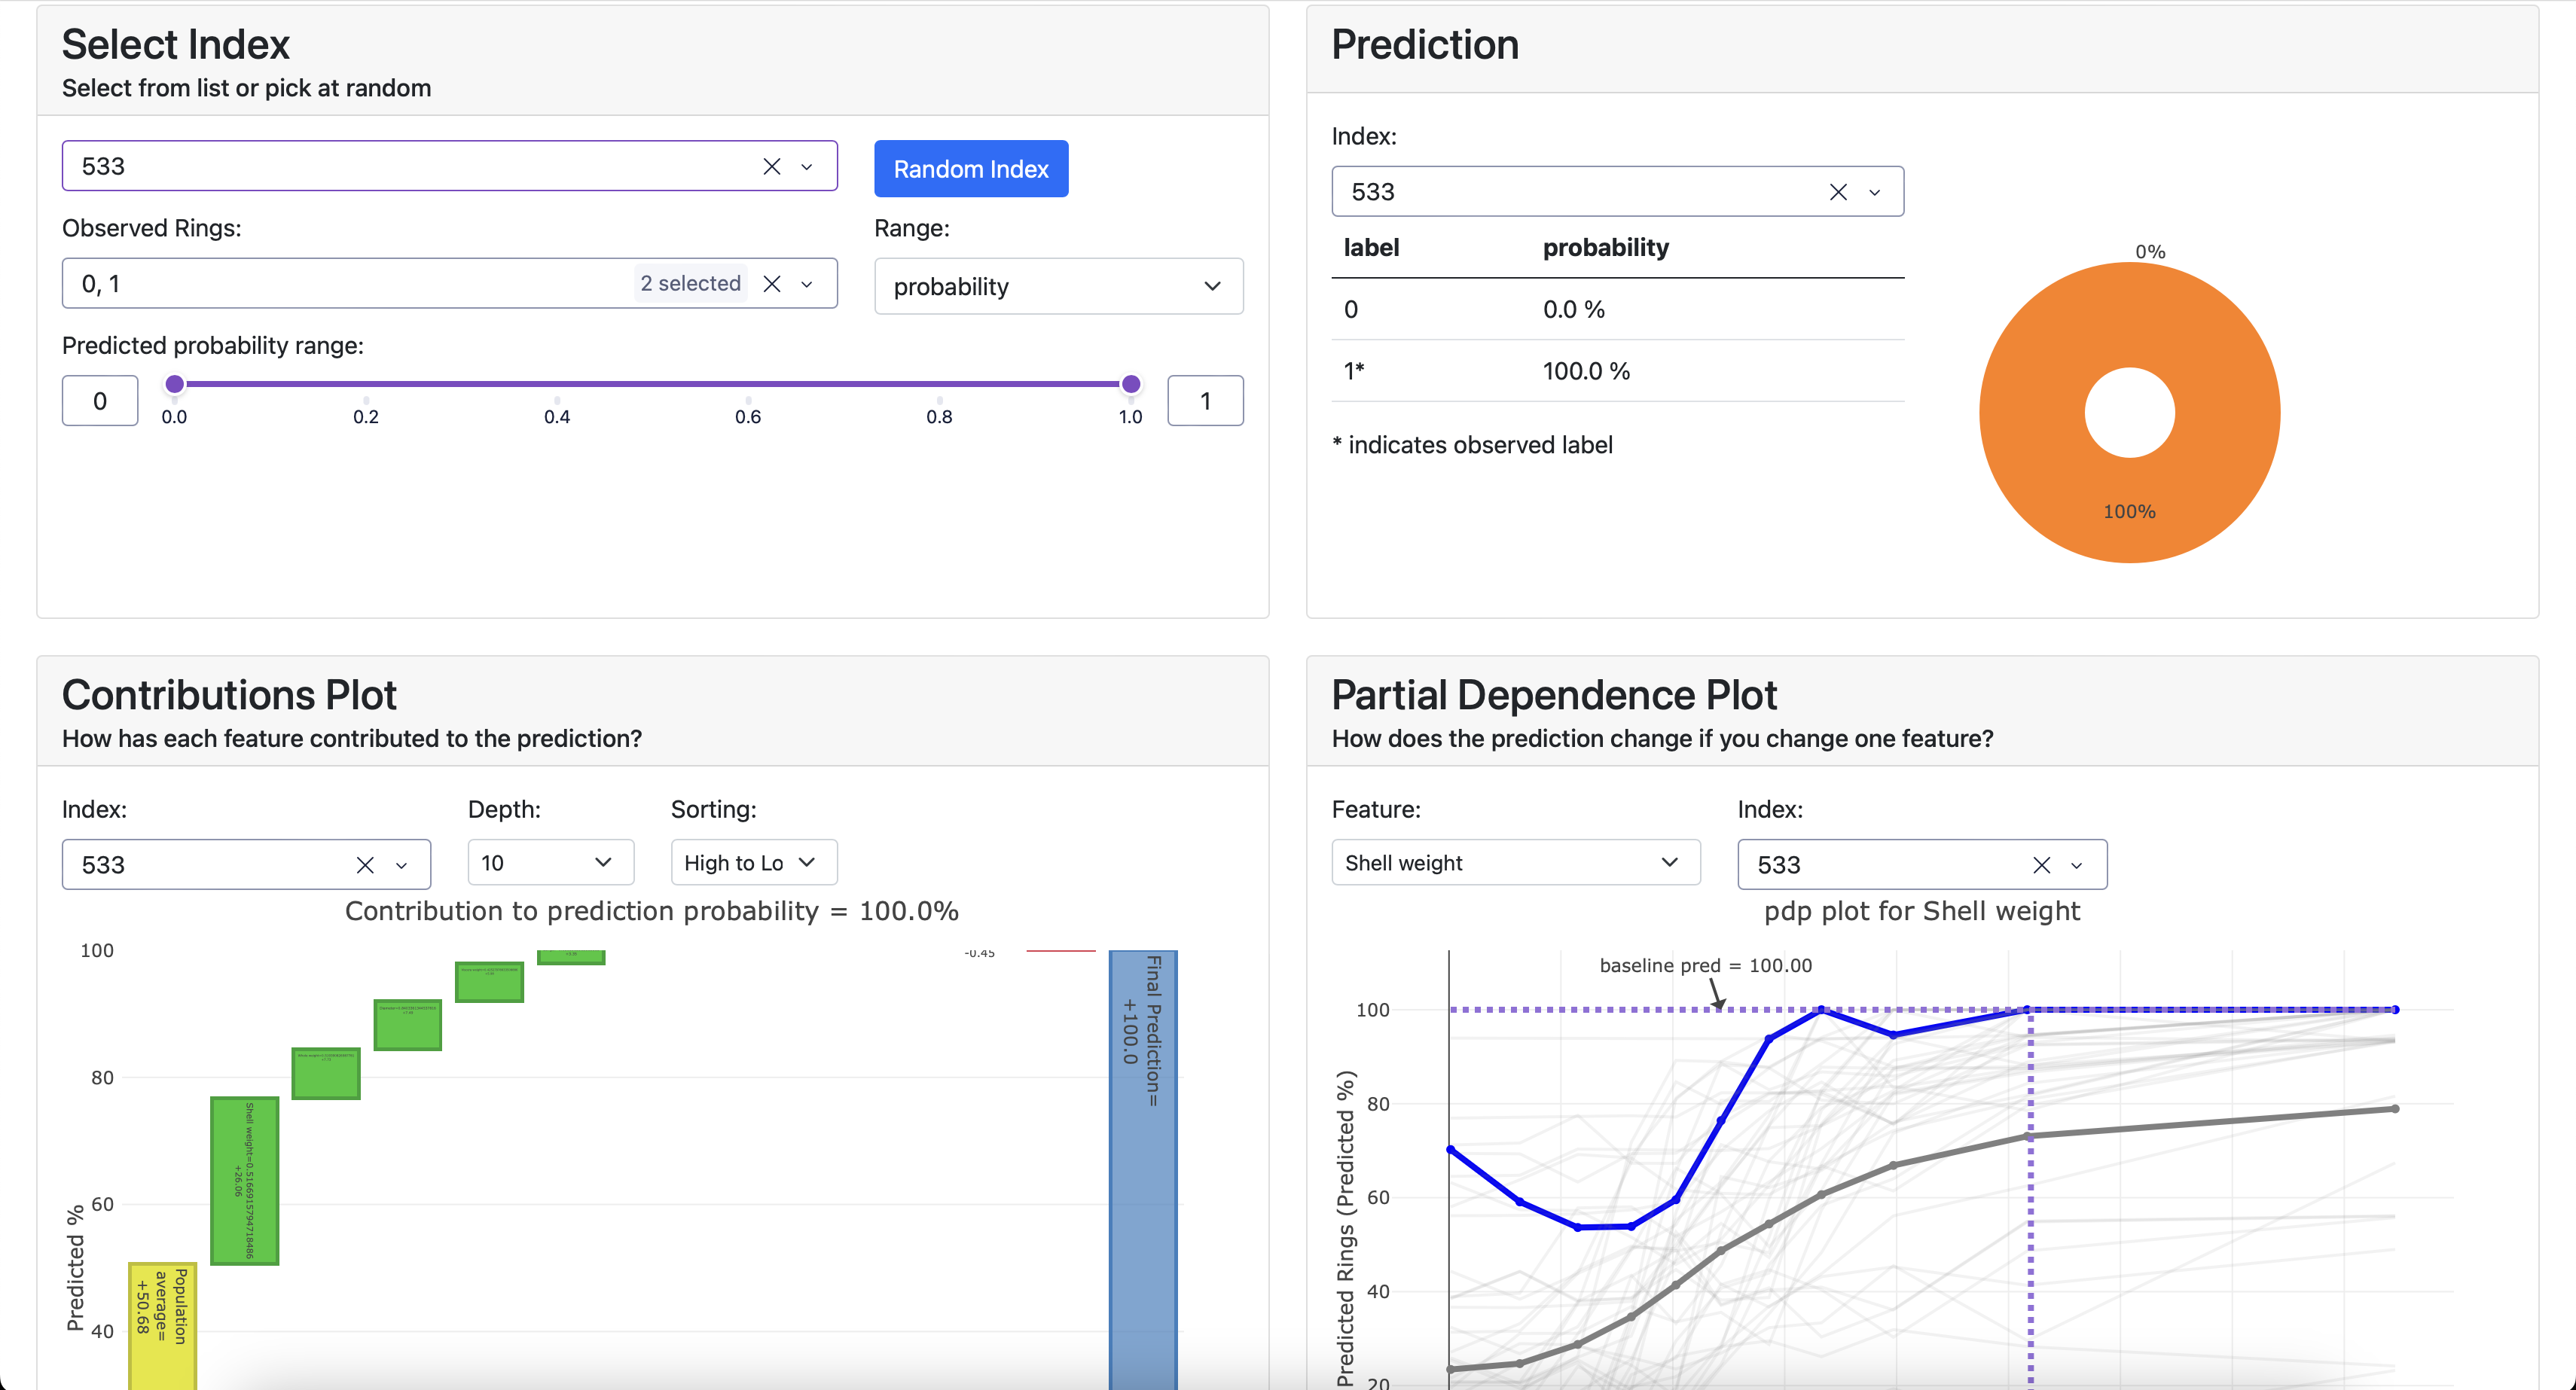

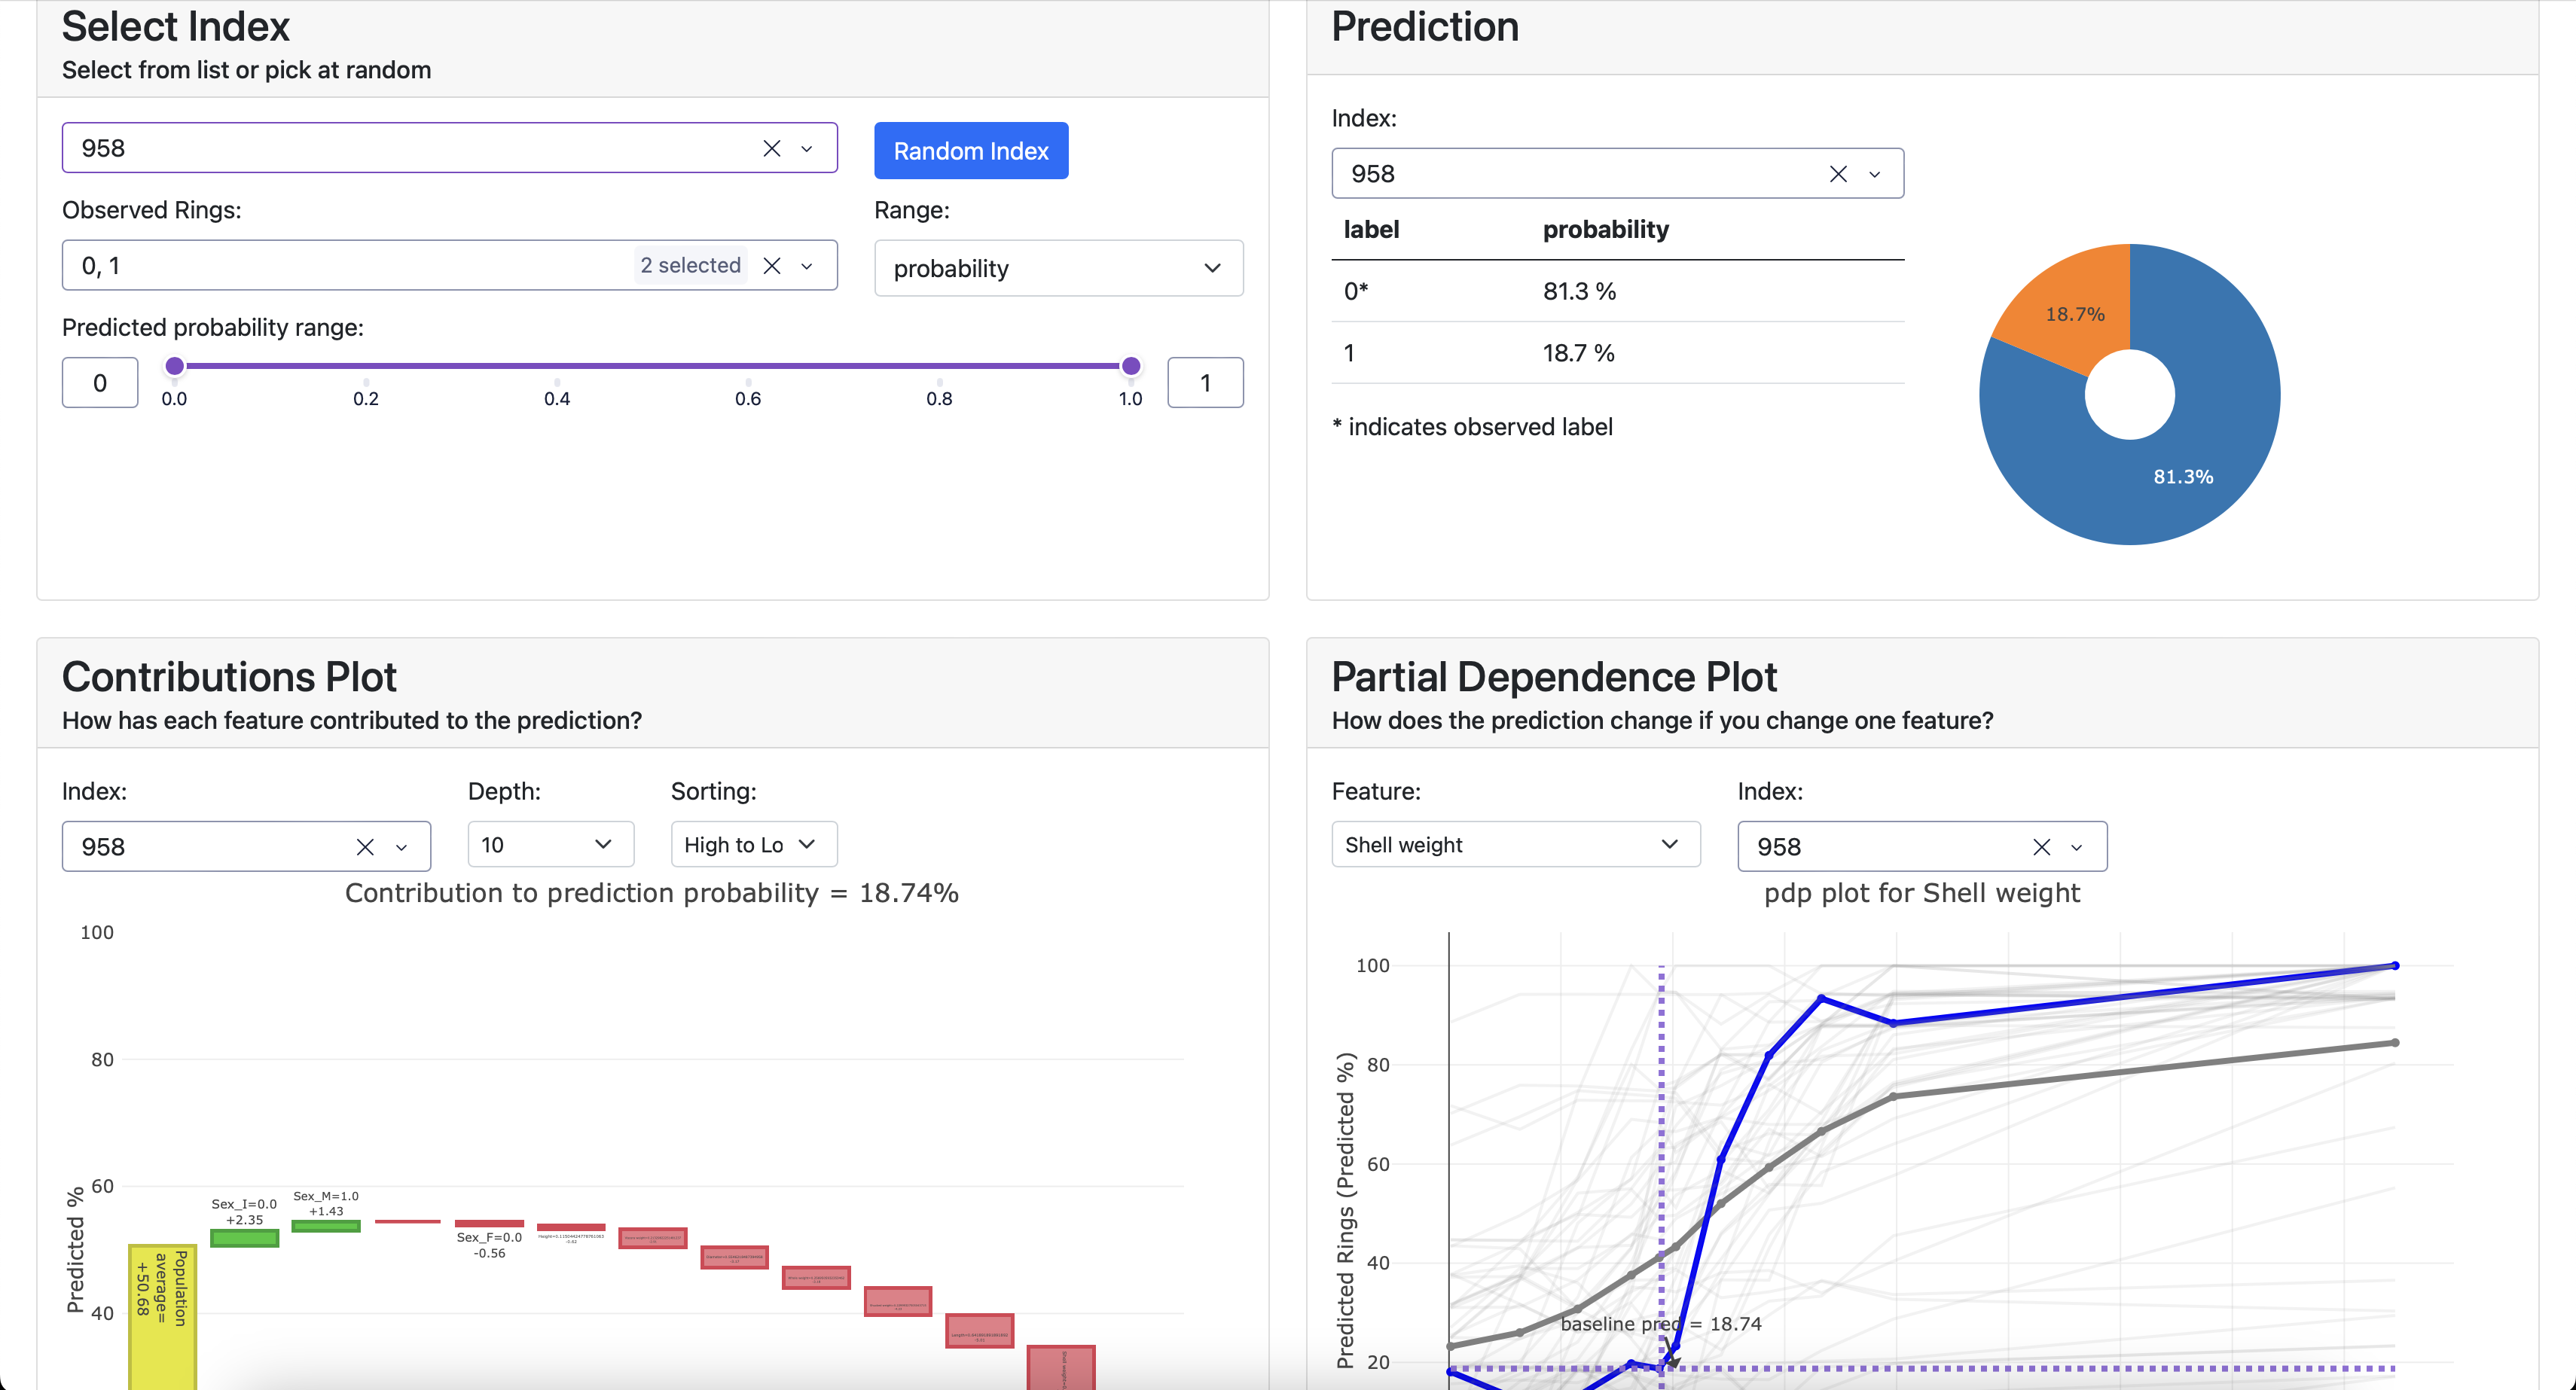

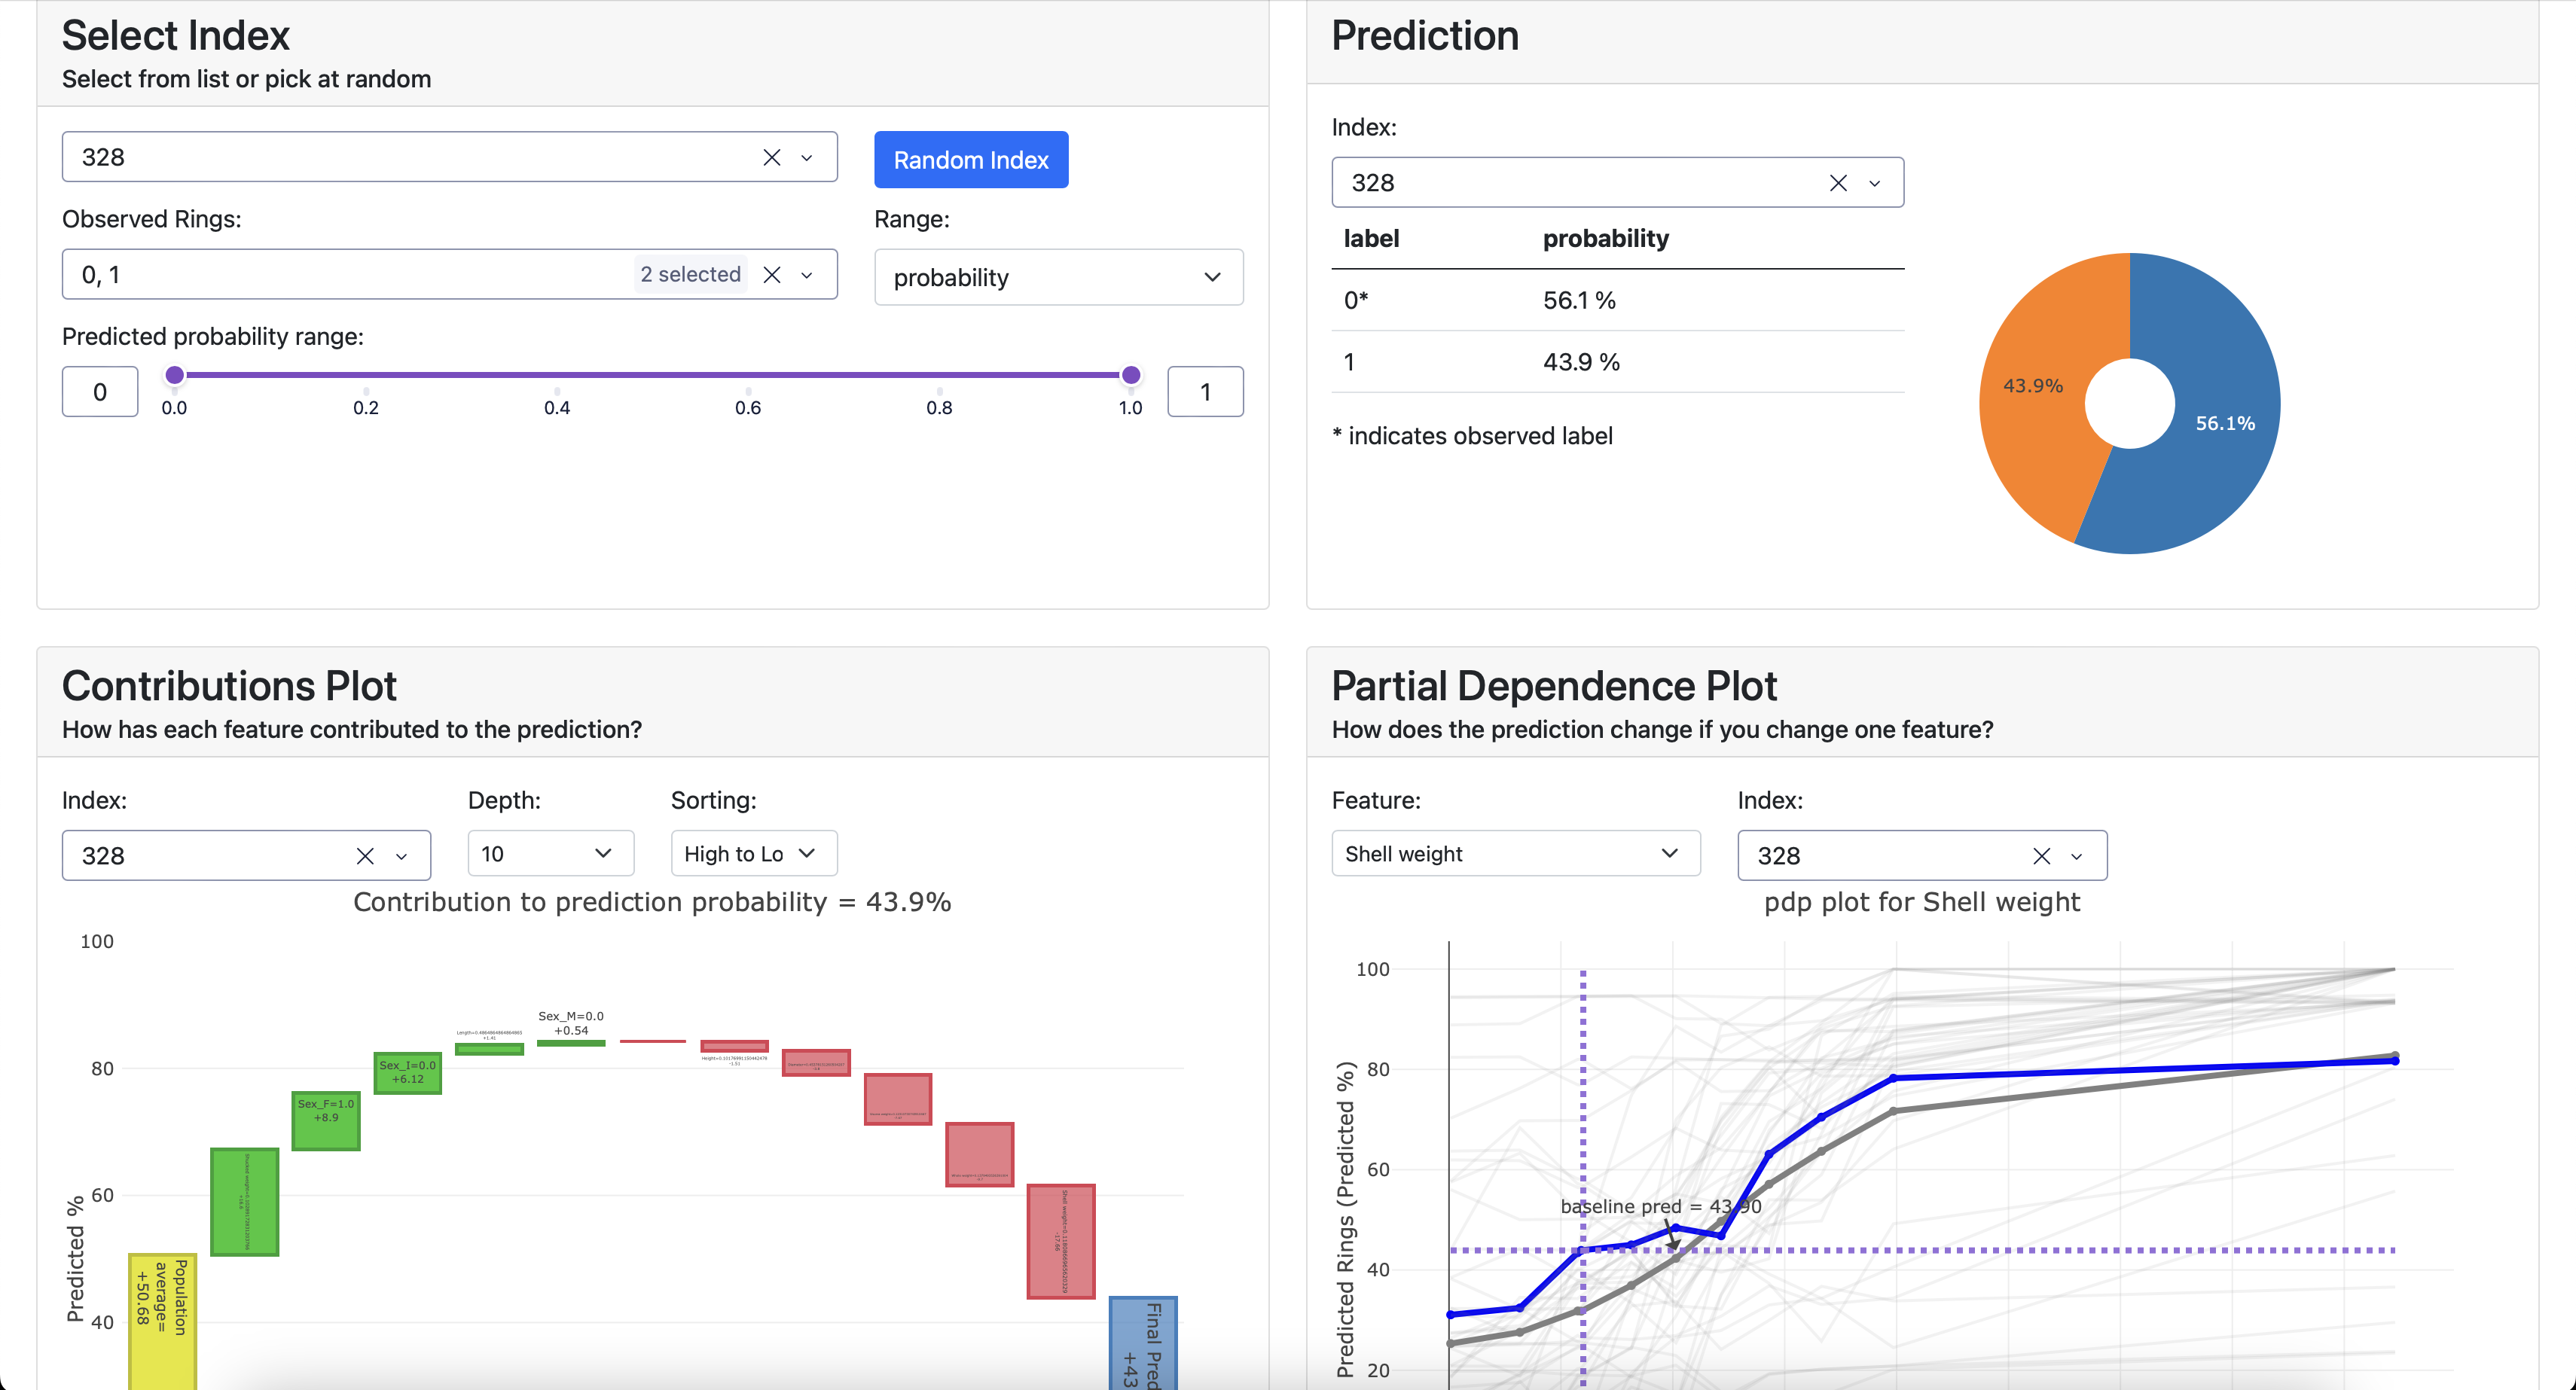

Рассмотрим некоторых абалонов

№533

у него вероятность была 50.68%, но каждый последующий признак прибавлял по несколько процентов, поэтому итоговый прогноз, что этот абалон с вероятностью 100% старый

№958

у него вероятность была 50.68%, то что он не детеныщ, а мужского рода пррибавило к его вероятности 3,78, но остальные эту вероятность вычитали, в особенности Shell weight, который вычил 16,05%. Итоговая вероятность, что он молодой 81.3%

№328

у него вероятность была 50.68%, пол, наибольшая длина раковины и масса мяса прибавили к верояности 33,57%, а такие признаки как высота с мясом внутри раковины, диаметр, масса внутренностей, масса всего абалона и масса раковины после сушки вычли 40,34% итого вероятность, что абалон молодой - 56,1%, а то что старый - 43,9